In [1]:
import os
import base64
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import math
import cv2

API_BASE_URL = "http://localhost:5000"
DATASET_PATH = "images/FOTOS JPG"

# Utils

In [2]:
def encode_image_to_base64(image_path: str) -> str:
    """
    Lê o arquivo binário do disco e aplica a codificação Base64 para tráfego via protocolo HTTP.

    Args:
        image_path (str): Caminho absoluto ou relativo para o arquivo de imagem.

    Returns:
        str: Sequência de caracteres Base64 representando a imagem.
    """
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

def register_face(api_url: str, person_name: str, image_b64: str) -> dict:
    """
    Executa a requisição HTTP POST para o endpoint de registro da API de reconhecimento facial.

    Args:
        api_url (str): URL base da API.
        person_name (str): Rótulo de identificação da pessoa.
        image_b64 (str): Imagem codificada em formato Base64.

    Returns:
        dict: Objeto JSON decodificado contendo a resposta do servidor.
    """
    url = f"{api_url}/register"
    payload = {"name": person_name, "image": image_b64}
    response = requests.post(url, json=payload)
    return response.json()

def recognize_face(api_url: str, image_b64: str) -> dict:
    """
    Executa a requisição HTTP POST para o endpoint de inferência da API.

    Args:
        api_url (str): URL base da API.
        image_b64 (str): Imagem codificada em formato Base64.

    Returns:
        dict: Objeto JSON decodificado contendo o resultado da predição e o score.
    """
    url = f"{api_url}/recognize"
    payload = {"image": image_b64}
    response = requests.post(url, json=payload)
    return response.json()

def build_dataset_and_register(base_path: str, api_url: str) -> pd.DataFrame:
    """
    Realiza a varredura do sistema de arquivos, cadastra a primeira imagem de cada indivíduo
    via API e constrói a estrutura de dados tabular para posterior validação.

    Args:
        base_path (str): Diretório raiz contendo as subpastas rotuladas.
        api_url (str): URL base da API de reconhecimento.

    Returns:
        pd.DataFrame: DataFrame contendo o mapeamento das imagens e o status de cadastro.
    """
    data = []
    
    for root, dirs, files in os.walk(base_path):
        if root == base_path:
            continue
            
        person_name = os.path.basename(root)
        image_files = sorted([f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        
        if not image_files:
            continue
            
        for index, file_name in enumerate(image_files):
            image_path = os.path.join(root, file_name)
            is_cad = (index == 0)
            
            if is_cad:
                img_b64 = encode_image_to_base64(image_path)
                register_face(api_url, person_name, img_b64)
                
            data.append({
                "image_path": image_path,
                "true_label": person_name,
                "is_cad": is_cad,
                "predicted_label": None,
                "score": None
            })
            
    return pd.DataFrame(data)

def process_predictions_for_subset(df: pd.DataFrame, api_url: str, condition_is_cad: bool) -> pd.DataFrame:
    """
    Submete um subconjunto específico do DataFrame ao endpoint de inferência e registra os resultados.

    Args:
        df (pd.DataFrame): DataFrame completo mapeando o dataset.
        api_url (str): URL base da API de reconhecimento.
        condition_is_cad (bool): Filtro booleano para definir o subconjunto alvo.

    Returns:
        pd.DataFrame: DataFrame com as colunas de predição e score atualizadas para o subconjunto.
    """
    indices = df[df['is_cad'] == condition_is_cad].index
    
    for idx in indices:
        img_b64 = encode_image_to_base64(df.at[idx, 'image_path'])
        result = recognize_face(api_url, img_b64)
        
        df.at[idx, 'predicted_label'] = result.get('result', 'Error')
        df.at[idx, 'score'] = result.get('score', 0.0)
        
    return df

def evaluate_metrics_and_plot(df: pd.DataFrame) -> None:
    """
    Calcula as métricas estatísticas globais do pipeline de inferência e renderiza a Matriz de Confusão.

    Args:
        df (pd.DataFrame): DataFrame contendo os rótulos verdadeiros e as predições computadas.
    """
    y_true = df['true_label'].tolist()
    y_pred = df['predicted_label'].tolist()
    
    labels = sorted(list(set(y_true) | set(y_pred)))
    
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
    
def build_test_dataset(base_path: str) -> pd.DataFrame:
    """
    Mapeia a estrutura de diretórios de um conjunto de validação externo, construindo
    o DataFrame estrutural com a flag de cadastro estritamente negativa.

    Args:
        base_path (str): Diretório raiz contendo as subpastas rotuladas.

    Returns:
        pd.DataFrame: DataFrame estrutural contendo os caminhos e rótulos verdadeiros.
    """
    data = []
    
    for root, dirs, files in os.walk(base_path):
        if root == base_path:
            continue
            
        person_name = os.path.basename(root)
        image_files = sorted([f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        
        for file_name in image_files:
            image_path = os.path.join(root, file_name)
            
            data.append({
                "image_path": image_path,
                "true_label": person_name,
                "is_cad": False,
                "predicted_label": None,
                "score": None
            })
            
    return pd.DataFrame(data)

def plot_misclassified_images(df: pd.DataFrame) -> None:
    """
    Renderiza um grid matricial contendo as amostras de imagens cujas inferências 
    divergiram da classe original (ground truth). Extrai o tensor diretamente do disco 
    para reconstrução visual no plot plot_misclassified_images.

    Args:
        df (pd.DataFrame): DataFrame contendo as colunas 'true_label', 'predicted_label' e 'image_path'.
    """
    df_errors = df[df['true_label'] != df['predicted_label']]
    
    if df_errors.empty:
        print("Métrica de erro zero. Nenhuma classificação divergente.")
        return

    num_errors = len(df_errors)
    cols = 4
    rows = math.ceil(num_errors / cols)
    
    plt.figure(figsize=(16, 4 * rows))
    
    for idx, (_, row) in enumerate(df_errors.iterrows()):
        plt.subplot(rows, cols, idx + 1)
        
        img = cv2.imread(row['image_path'])
        if img is not None:
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            plt.imshow(img_rgb)
            
        true_lbl = row['true_label']
        pred_lbl = row['predicted_label']
        
        plt.title(f"Nome: {true_lbl}\ne identificado como {pred_lbl}", fontsize=11, color='darkred', weight='bold')
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()
    
def reset_qdrant_database(api_url: str) -> dict:
    """
    Executa a requisição HTTP DELETE para o endpoint de expurgo da API de reconhecimento.

    Args:
        api_url (str): URL base da API.

    Returns:
        dict: Objeto JSON decodificado contendo a resposta do servidor.
    """
    url = f"{api_url}/reset"
    response = requests.delete(url)
    return response.json()

reset_qdrant_database(API_BASE_URL)

{'message': 'Banco de dados limpo com sucesso'}

# Code and Execution

In [3]:


df_faces = build_dataset_and_register(DATASET_PATH, API_BASE_URL)
display(df_faces.head())

,image_path,true_label,is_cad,predicted_label,score
0,images/FOTOS JPG/BRUNO/IMG_6700.jpg,BRUNO,True,None,None
1,images/FOTOS JPG/BRUNO/IMG_6701.jpg,BRUNO,False,None,None
2,images/FOTOS JPG/BRUNO/IMG_6702.jpg,BRUNO,False,None,None
3,images/FOTOS JPG/BRUNO/IMG_6703.jpg,BRUNO,False,None,None
4,images/FOTOS JPG/BRUNO/IMG_6704.jpg,BRUNO,False,None,None


In [4]:
df_faces = process_predictions_for_subset(df_faces, API_BASE_URL, condition_is_cad=True)
display(df_faces[df_faces['is_cad'] == True].head())

,image_path,true_label,is_cad,predicted_label,score
0,images/FOTOS JPG/BRUNO/IMG_6700.jpg,BRUNO,True,BRUNO,1.0
15,images/FOTOS JPG/FREDERICO/IMG_6677.jpg,FREDERICO,True,FREDERICO,1.0
26,images/FOTOS JPG/ISABELLA/IMG_6644.jpg,ISABELLA,True,ISABELLA,1.0
30,images/FOTOS JPG/KARLL/IMG_6739.jpg,KARLL,True,KARLL,1.0
42,images/FOTOS JPG/LARISSA/IMG_6651.jpg,LARISSA,True,LARISSA,1.0


In [5]:
df_faces = process_predictions_for_subset(df_faces, API_BASE_URL, condition_is_cad=False)
display(df_faces[df_faces['is_cad'] == False].head())

,image_path,true_label,is_cad,predicted_label,score
1,images/FOTOS JPG/BRUNO/IMG_6701.jpg,BRUNO,False,BRUNO,0.955473
2,images/FOTOS JPG/BRUNO/IMG_6702.jpg,BRUNO,False,BRUNO,0.819649
3,images/FOTOS JPG/BRUNO/IMG_6703.jpg,BRUNO,False,BRUNO,0.809348
4,images/FOTOS JPG/BRUNO/IMG_6704.jpg,BRUNO,False,BRUNO,0.854362
5,images/FOTOS JPG/BRUNO/IMG_6705.jpg,BRUNO,False,BRUNO,0.861862


Accuracy:  0.9286
Precision: 1.0000
Recall:    0.9286
F1-Score:  0.9554


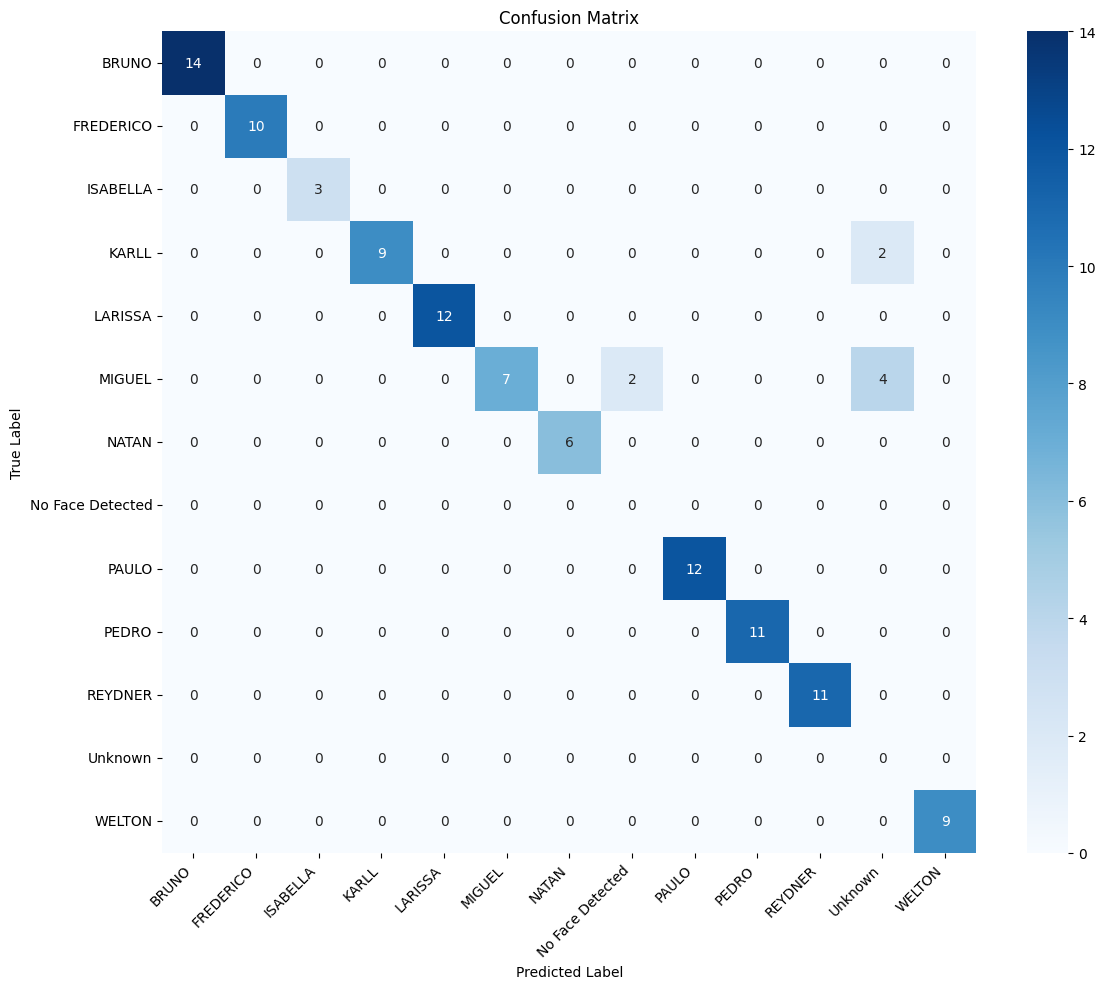

In [6]:
evaluate_metrics_and_plot(df_faces[df_faces['is_cad'] == False])


Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000


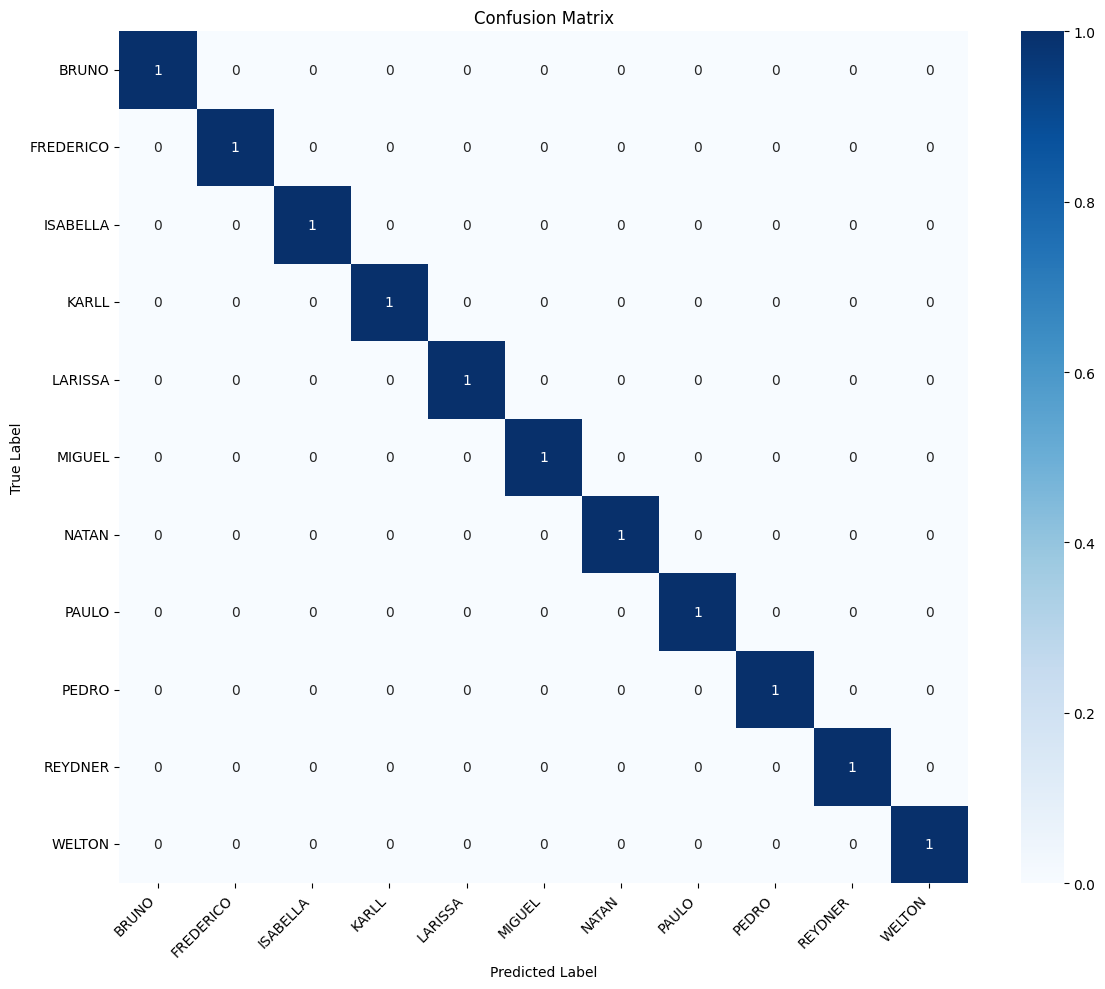

In [7]:
evaluate_metrics_and_plot(df_faces[df_faces['is_cad'] == True])


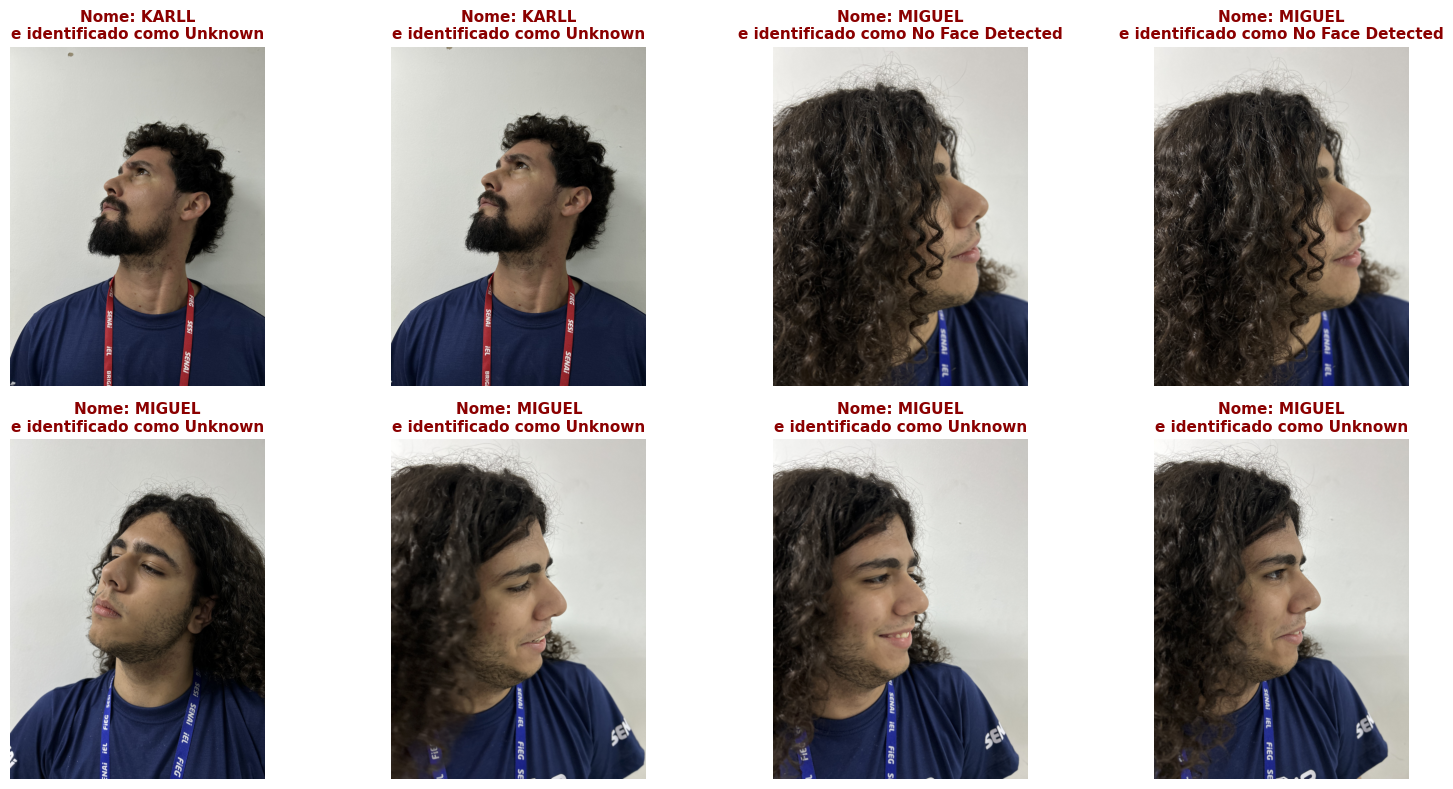

In [8]:
plot_misclassified_images(df_faces[df_faces['is_cad'] == False])

## Test data

,image_path,true_label,is_cad,predicted_label,score
0,images/DATASET WEBCAM/BRUNO/foto_00009.jpg,BRUNO,False,BRUNO,0.739042
1,images/DATASET WEBCAM/BRUNO/foto_00010.jpg,BRUNO,False,BRUNO,0.773607
2,images/DATASET WEBCAM/BRUNO/foto_00011.jpg,BRUNO,False,BRUNO,0.796394
3,images/DATASET WEBCAM/FREDERICO/foto_00080.jpg,FREDERICO,False,FREDERICO,0.799421
4,images/DATASET WEBCAM/FREDERICO/foto_00089.jpg,FREDERICO,False,FREDERICO,0.736719


Accuracy:  0.9524
Precision: 1.0000
Recall:    0.9524
F1-Score:  0.9714


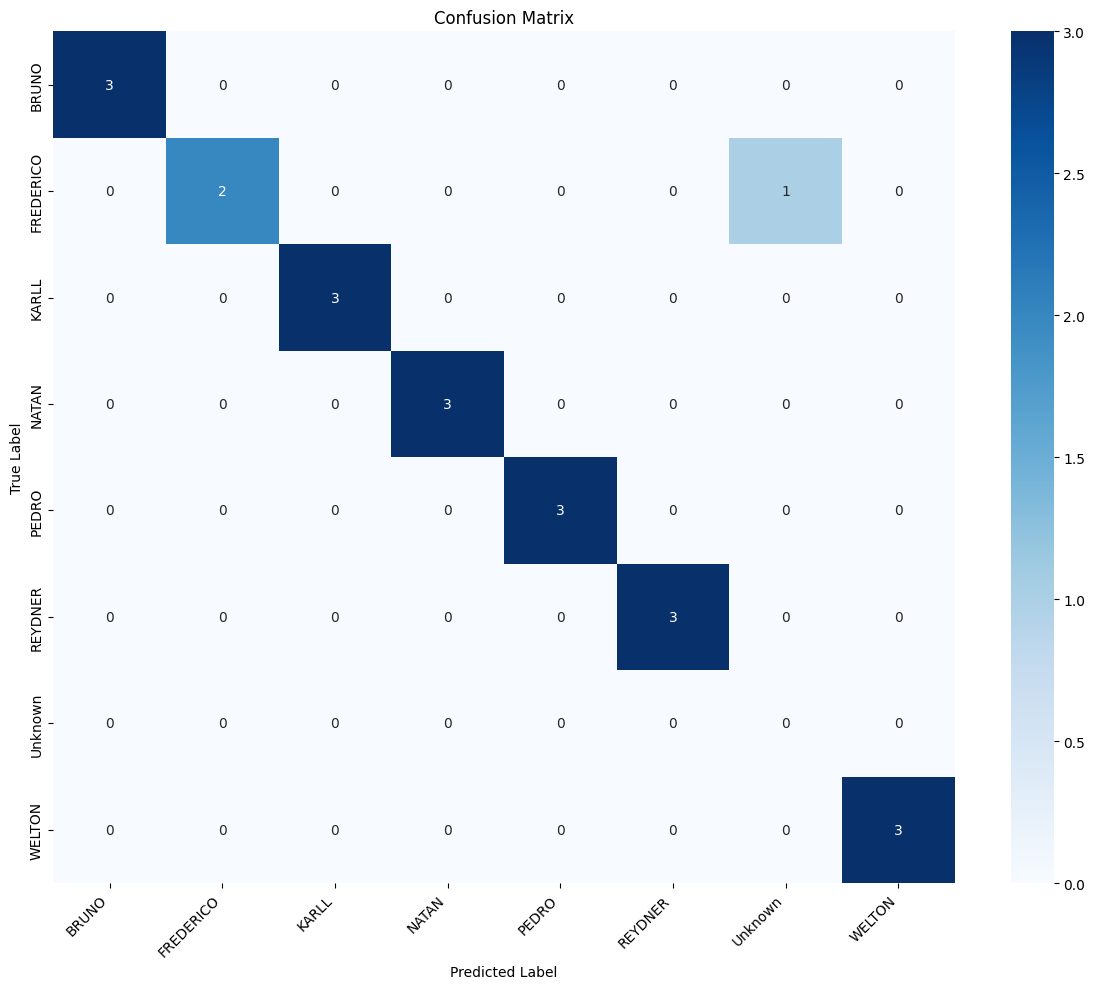

In [9]:
test_path  ="images/DATASET WEBCAM"
df_test_extra = build_test_dataset(test_path)

df_test_extra = process_predictions_for_subset(df_test_extra, API_BASE_URL, condition_is_cad=False)
display(df_test_extra.head())
evaluate_metrics_and_plot(df_test_extra)

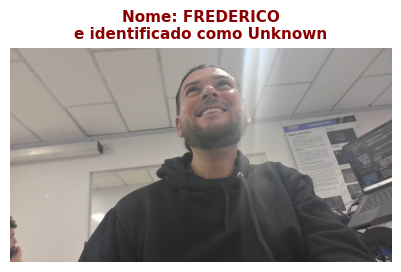

In [10]:
plot_misclassified_images(df_test_extra)

In [11]:
df_faces.score.sort_values().values

array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.52057815, 0.52482253,
       0.54846257, 0.5495727, 0.5562211, 0.5700508, 0.5724915, 0.57862943,
       0.57952815, 0.5839506, 0.5885488, 0.5939523, 0.59480834, 0.5970213,
       0.6128039, 0.6174687, 0.6232563, 0.63368297, 0.6402969, 0.64157647,
       0.64755726, 0.6527854, 0.6531464, 0.6596273, 0.6609633, 0.68236053,
       0.6860643, 0.6881876, 0.6934265, 0.69355655, 0.6939287, 0.7010979,
       0.70197093, 0.7206222, 0.723042, 0.73090136, 0.7314717, 0.7315714,
       0.7372156, 0.73903644, 0.74597913, 0.7528001, 0.7557638, 0.7576259,
       0.7601461, 0.7614272, 0.7617552, 0.76350945, 0.76837337,
       0.76939875, 0.7747371, 0.7750495, 0.78606594, 0.78924507,
       0.79050565, 0.79169995, 0.7936719, 0.8017291, 0.8061892, 0.8063811,
       0.8093476, 0.8097436, 0.8105391, 0.8124417, 0.8146554, 0.81944203,
       0.8196485, 0.8212563, 0.82452023, 0.8352742, 0.83770406,
       0.83897406, 0.8466399, 0.8541868, 0.85436225, 0.85764843,